<a href="https://colab.research.google.com/github/SattamAltwaim/EVE/blob/main/benchmarks/benchmark_cifar10_cnn_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVE Optimizer Benchmark: CIFAR-10 on CNN & ViT

**EVE (ρ=0.58, K=4)** vs **SGD**, **AdamW**, **RMSProp** on CIFAR-10.

### Focus
- **Time to converge** (wall-clock seconds to target accuracy)
- **Optimizer metrics**: steps/sec, time per epoch, overhead
- **Results**: best validation accuracy

### Architectures
- Small CNN (4-block ConvNet)
- ViT-Tiny (compact vision transformer)

### Fast Colab run
Uses subset of CIFAR-10 (~10k train) and 30 epochs. ~5–10 min on A100.

In [1]:
# ── 0. Setup ─────────────────────────────────────────────────────────────
# Colab: clone repo. Local: pip install -e . or run from repo root
import os, sys, subprocess
if os.path.exists("/content"):
    subprocess.run(["git", "clone", "https://github.com/SattamAltwaim/EVE.git", "/content/EVE"],
                   capture_output=True, check=False)
    if "/content/EVE" not in sys.path:
        sys.path.insert(0, "/content/EVE")
else:
    parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if os.path.exists(os.path.join(parent, "eve_optimizer")) and parent not in sys.path:
        sys.path.insert(0, parent)

from eve_optimizer import EVE
print("EVE imported successfully")

EVE imported successfully


In [2]:
# ── 1. Imports & Config ──────────────────────────────────────────────────
import math
import time
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

from eve_optimizer import EVE

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

EVE_RHO, EVE_K = 0.58, 4
EPOCHS = 30
BATCH_SIZE = 128
SUBSET_SIZE = 10000  # use subset for fast run

Device: cuda
  GPU: NVIDIA A100-SXM4-40GB


In [3]:
# ── 2. CIFAR-10 data (subset for speed) ───────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

def get_cifar10_loaders(batch_size=128, subset_size=10000):
    train_tf = T.Compose([
        T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(),
        T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    test_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])
    train_ds = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_tf)
    test_ds = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_tf)

    if subset_size < len(train_ds):
        indices = torch.randperm(len(train_ds))[:subset_size].tolist()
        train_ds = Subset(train_ds, indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size * 2, shuffle=False, num_workers=2)
    return train_loader, test_loader

train_loader, test_loader = get_cifar10_loaders(BATCH_SIZE, SUBSET_SIZE)
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Train batches: 78, Test batches: 40


In [4]:
# ── 3. CNN & ViT models ───────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, pool=False):
        super().__init__()
        layers = [
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64), ConvBlock(64, 128, pool=True),
            ConvBlock(128, 256, pool=True), ConvBlock(256, 256, pool=True),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=3, patch_size=4, d_model=128, img_size=32):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, d_model, patch_size, stride=patch_size)
        n_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        return x + self.pos_embed

class ViTTiny(nn.Module):
    def __init__(self, num_classes=10, patch_size=4, d_model=128, nhead=4, num_layers=4):
        super().__init__()
        self.embed = PatchEmbedding(3, patch_size, d_model)
        enc = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_model*2, dropout=0.1, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        return self.head(self.norm(x[:, 0]))

In [5]:
# ── 4. Optimizer factory & training ──────────────────────────────────────
@dataclass
class EpochMetrics:
    train_loss: float
    val_acc: float
    epoch_time: float
    steps_per_sec: float
    epoch: int

def make_optimizer(name: str, model: nn.Module, lr: float = 1e-3, wd: float = 0.01):
    if name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    elif name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif name == "RMSProp":
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    elif name == "EVE":
        return EVE(model.parameters(), lr=lr, weight_decay=wd, K=EVE_K, rho=EVE_RHO)
    raise ValueError(f"Unknown: {name}")

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

def train_one_epoch(model, loader, optimizer, device, opt_name):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        if opt_name == "EVE":
            optimizer.step(model=model, loss_fn=F.cross_entropy, data=(x, y))
        else:
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        n += y.size(0)
    return total_loss / n

In [6]:
# ── 5. Benchmark runner ─────────────────────────────────────────────────
ARCHS = ["CNN", "ViT-Tiny"]
OPTS = ["SGD", "AdamW", "RMSProp", "EVE"]
LR_MAP = {"SGD": 0.1, "AdamW": 1e-3, "RMSProp": 1e-3, "EVE": 1e-3}
TARGET_ACC = 0.75

def make_model(arch: str):
    if arch == "CNN":
        return CNN()
    elif arch == "ViT-Tiny":
        return ViTTiny()
    raise ValueError(arch)

def run_benchmark(seed=42):
    results = defaultdict(dict)
    for arch in ARCHS:
        print(f"\n{'='*60}\n  {arch}\n{'='*60}")
        for opt_name in OPTS:
            torch.manual_seed(seed)
            model = make_model(arch).to(DEVICE)
            optimizer = make_optimizer(opt_name, model, LR_MAP[opt_name])

            history = []
            cum_time = 0.0
            time_to_target = None
            for ep in range(1, EPOCHS + 1):
                t0 = time.perf_counter()
                tr_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, opt_name)
                elapsed = time.perf_counter() - t0
                cum_time += elapsed
                val_acc = evaluate(model, test_loader, DEVICE)
                sps = len(train_loader) / elapsed if elapsed > 0 else 0
                history.append(EpochMetrics(tr_loss, val_acc, elapsed, sps, ep))
                if time_to_target is None and val_acc >= TARGET_ACC:
                    time_to_target = cum_time
                if ep % 10 == 0 or ep == 1:
                    print(f"  {opt_name:8} ep={ep:2d} loss={tr_loss:.4f} val_acc={val_acc:.4f} {elapsed:.1f}s")

            results[arch][opt_name] = {
                "history": history,
                "time_to_target": time_to_target,
                "best_val_acc": max(h.val_acc for h in history),
                "total_time": cum_time,
            }
            del model, optimizer
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
    return results

In [7]:
# ── 6. Run benchmark ─────────────────────────────────────────────────────
results = run_benchmark()


  CNN
  SGD      ep= 1 loss=1.9522 val_acc=0.2014 3.6s
  SGD      ep=10 loss=1.4599 val_acc=0.3275 2.0s
  SGD      ep=20 loss=1.4582 val_acc=0.1682 2.0s
  SGD      ep=30 loss=1.4913 val_acc=0.3301 2.0s
  AdamW    ep= 1 loss=1.7235 val_acc=0.4367 2.1s
  AdamW    ep=10 loss=0.8533 val_acc=0.5881 2.0s
  AdamW    ep=20 loss=0.6014 val_acc=0.6574 2.0s
  AdamW    ep=30 loss=0.4168 val_acc=0.6781 2.0s
  RMSProp  ep= 1 loss=1.8718 val_acc=0.2641 2.0s
  RMSProp  ep=10 loss=1.2883 val_acc=0.2614 2.1s
  RMSProp  ep=20 loss=1.0222 val_acc=0.3170 2.0s
  RMSProp  ep=30 loss=0.8785 val_acc=0.5996 2.0s
  EVE      ep= 1 loss=1.6787 val_acc=0.4323 2.4s
  EVE      ep=10 loss=0.8702 val_acc=0.6136 2.1s
  EVE      ep=20 loss=0.6247 val_acc=0.6288 2.0s
  EVE      ep=30 loss=0.4437 val_acc=0.7021 2.1s

  ViT-Tiny
  SGD      ep= 1 loss=2.1602 val_acc=0.2448 2.3s
  SGD      ep=10 loss=2.2120 val_acc=0.1525 2.0s
  SGD      ep=20 loss=2.3043 val_acc=0.1000 2.3s
  SGD      ep=30 loss=2.3053 val_acc=0.1000 2.1s
 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:921: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_transformer_encoder_layer_fwd. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:80.)
  return torch._transformer_encoder_layer_fwd(


  EVE      ep= 1 loss=2.0368 val_acc=0.2901 4.5s
  EVE      ep=10 loss=1.3169 val_acc=0.5292 4.4s
  EVE      ep=20 loss=1.0939 val_acc=0.5893 4.4s
  EVE      ep=30 loss=0.9097 val_acc=0.5920 4.3s


In [8]:
# ── 7. Optimizer metrics & results ───────────────────────────────────────
print("=" * 80)
print("  OPTIMIZER METRICS — Time to Converge & Efficiency")
print("=" * 80)
for arch in ARCHS:
    print(f"\n{arch} (target val_acc >= {TARGET_ACC})")
    print("-" * 60)
    print(f"{'Optimizer':<10} {'Time to target (s)':<20} {'Best val_acc':<14} {'Total time (s)':<14} {'Avg s/epoch':<12}")
    for opt in OPTS:
        r = results[arch][opt]
        tt = f"{r['time_to_target']:.2f}" if r["time_to_target"] else "N/A"
        avg_ep = r["total_time"] / EPOCHS
        print(f"{opt:<10} {tt:<20} {r['best_val_acc']:.4f}          {r['total_time']:.2f}          {avg_ep:.3f}")

# Overhead: EVE vs AdamW
print("\n--- EVE vs AdamW overhead (time per epoch) ---")
for arch in ARCHS:
    t_adamw = results[arch]["AdamW"]["total_time"] / EPOCHS
    t_eve = results[arch]["EVE"]["total_time"] / EPOCHS
    oh = (t_eve / t_adamw - 1) * 100
    print(f"  {arch}: AdamW={t_adamw:.2f}s/ep, EVE={t_eve:.2f}s/ep, overhead={oh:.1f}%")

  OPTIMIZER METRICS — Time to Converge & Efficiency

CNN (target val_acc >= 0.75)
------------------------------------------------------------
Optimizer  Time to target (s)   Best val_acc   Total time (s) Avg s/epoch 
SGD        N/A                  0.4227          62.95          2.098
AdamW      N/A                  0.7122          61.16          2.039
RMSProp    N/A                  0.6188          61.19          2.040
EVE        N/A                  0.7352          62.12          2.071

ViT-Tiny (target val_acc >= 0.75)
------------------------------------------------------------
Optimizer  Time to target (s)   Best val_acc   Total time (s) Avg s/epoch 
SGD        N/A                  0.2448          63.92          2.131
AdamW      N/A                  0.6424          63.33          2.111
RMSProp    N/A                  0.3319          63.54          2.118
EVE        N/A                  0.6269          134.01          4.467

--- EVE vs AdamW overhead (time per epoch) ---
  CNN: Ada

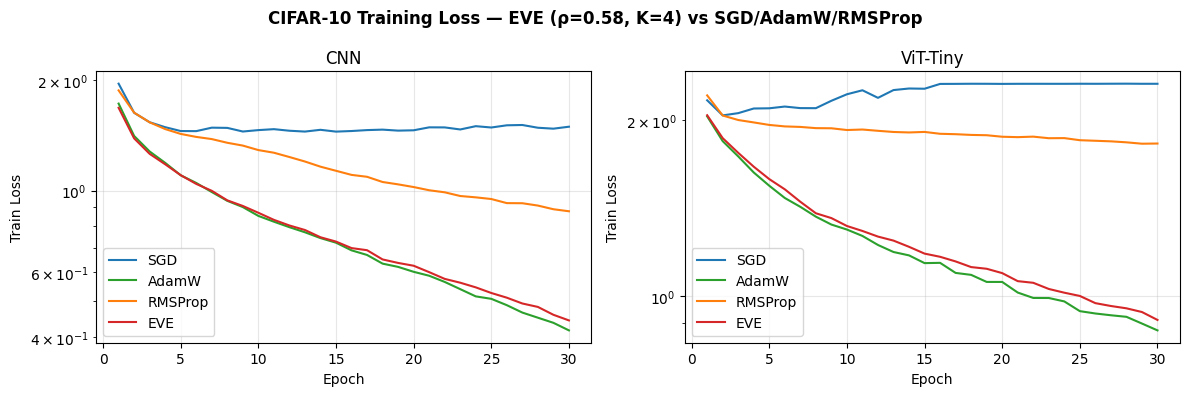

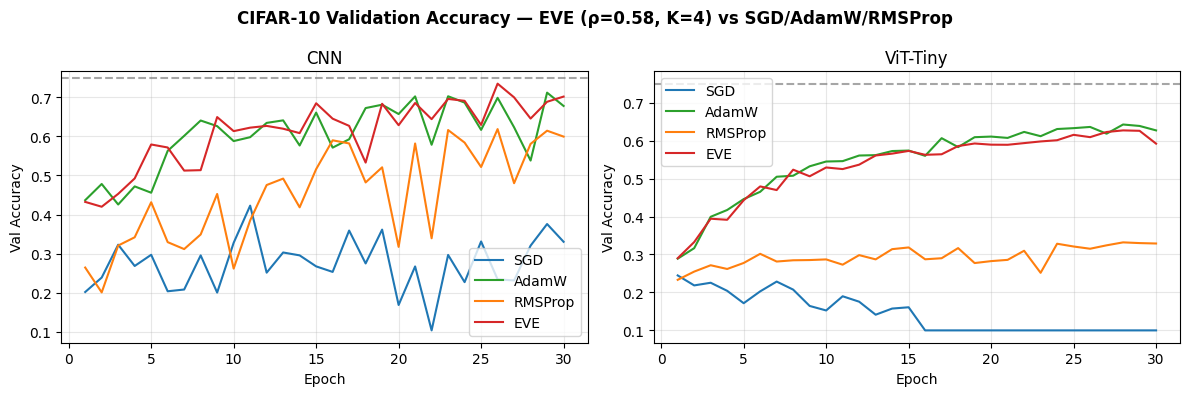

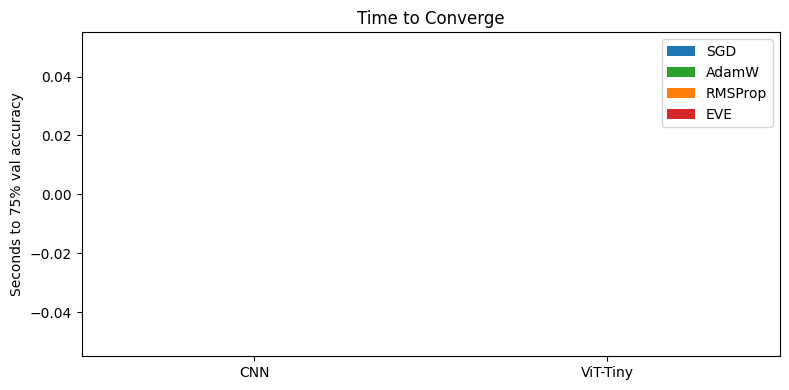

In [9]:
# ── 8. Plots ─────────────────────────────────────────────────────────────
colors = {"SGD": "#1f77b4", "AdamW": "#2ca02c", "RMSProp": "#ff7f0e", "EVE": "#d62728"}

# Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arch in zip(axes, ARCHS):
    for opt in OPTS:
        hist = results[arch][opt]["history"]
        ax.plot([h.epoch for h in hist], [h.train_loss for h in hist], label=opt, color=colors[opt])
    ax.set_title(arch)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("CIFAR-10 Training Loss — EVE (ρ=0.58, K=4) vs SGD/AdamW/RMSProp", fontweight="bold")
plt.tight_layout()
plt.show()

# Validation accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arch in zip(axes, ARCHS):
    for opt in OPTS:
        hist = results[arch][opt]["history"]
        ax.plot([h.epoch for h in hist], [h.val_acc for h in hist], label=opt, color=colors[opt])
    ax.axhline(TARGET_ACC, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(arch)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("CIFAR-10 Validation Accuracy — EVE (ρ=0.58, K=4) vs SGD/AdamW/RMSProp", fontweight="bold")
plt.tight_layout()
plt.show()

# Time to target
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ARCHS))
width = 0.2
for i, opt in enumerate(OPTS):
    vals = [results[a][opt]["time_to_target"] or 0 for a in ARCHS]
    ax.bar(x + i * width, vals, width, label=opt, color=colors[opt])
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(ARCHS)
ax.set_ylabel("Seconds to 75% val accuracy")
ax.set_title("Time to Converge")
ax.legend()
plt.tight_layout()
plt.show()